# Homework 5

David Godovich  
4/1/2026

In [1]:
# I don't use colab but have a fork of the class repo
# Run this to set up colab file structure
# %cd /content
# !rm -rf MOL518-Intro-to-Data-Analysis

# !git clone https://github.com/dgodovich/MOL518-Intro-to-Data-Analysis.git
# %cd MOL518-Intro-to-Data-Analysis/Homework_5

In [2]:
# I use uv as a package manager, install biopython
#!uv pip install biopython

In [3]:
import gzip # gzip to put the fastq in github
from Bio import SeqIO
from collections import Counter
import matplotlib.pyplot as plt

In [4]:
with gzip.open('FL-Algae-1-raw_1.fastq.gz', 'rt') as handle:
    algae = list(SeqIO.parse(handle, format='fastq'))

### a

In [5]:
# compute average quality score for each read and keep track of which ones are above 30
average_quality = []
quality_filter = []
for record in algae:
    quality_scores = record.letter_annotations["phred_quality"]
    average = sum(quality_scores)/len(quality_scores)
    average_quality.append(average)
    if average >= 30:
        quality_filter.append(True)
    else:
        quality_filter.append(False)

In [6]:
sum(quality_filter)

192176

In [7]:
# filter algae using quality_filter from above
algae_pass = [d for d, s in zip(algae, quality_filter) if s]

### b

In [8]:
SeqIO.write(algae_pass, 'FL-Algae-1-quality_filter_1.fastq', 'fastq')

192176

In [14]:
!gzip -f FL-Algae-1-quality_filter_1.fastq

### c

In [10]:
rounded_quality = [round(x) for x in average_quality]

In [11]:
quality_count = Counter(rounded_quality)

In [12]:
quality_count

Counter({36: 94521,
         37: 44575,
         35: 28378,
         34: 11197,
         33: 5682,
         32: 3748,
         31: 2871,
         30: 2209,
         29: 1794,
         28: 1395,
         27: 1146,
         26: 850,
         25: 583,
         24: 369,
         23: 254,
         22: 178,
         21: 103,
         20: 55,
         19: 44,
         18: 23,
         17: 16,
         16: 8,
         15: 1})

### d

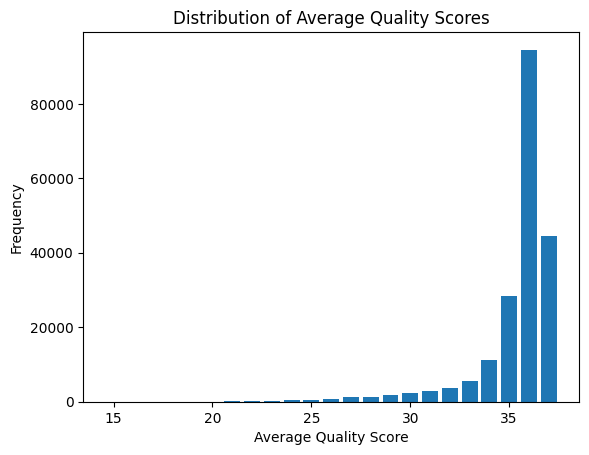

In [13]:
plt.bar(quality_count.keys(), quality_count.values())
plt.title('Distribution of Average Quality Scores')
plt.xlabel('Average Quality Score')
plt.ylabel('Frequency')
plt.show()